# Import the Libraries

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.model_selection import StratifiedKFold, cross_validate

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

from sklearn.metrics import (roc_auc_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix)

import joblib


# Import File

In [2]:
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

In [3]:
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "blastchar/telco-customer-churn",
  file_path,)

print("First 5 records:", df.head())

/tmp/ipykernel_5456/2513142274.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:    customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

# Pre Processing and Cleaning

In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df = df.drop(columns=['customerID']) # ID does not required

In [7]:
df.sample(5)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4246,Male,0,Yes,Yes,68,Yes,Yes,Fiber optic,Yes,Yes,Yes,No,Yes,Yes,Two year,Yes,Electronic check,110.20,7467.5,No
5660,Female,0,No,Yes,44,Yes,Yes,DSL,No,Yes,No,No,Yes,Yes,One year,Yes,Mailed check,77.55,3471.1,No
2280,Female,1,No,No,8,Yes,Yes,Fiber optic,No,No,No,Yes,Yes,Yes,Month-to-month,Yes,Credit card (automatic),100.15,908.55,No
2450,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),110.45,8058.85,No
1487,Female,0,No,No,56,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Electronic check,106.80,5914.4,No


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce', ) #Charges is shoud be numeric others categoty will handle later

Finding Uniques

In [9]:
df.nunique().sort_values() #finding and understading uniques from data

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
PhoneService,2
PaperlessBilling,2
Churn,2
InternetService,3
TechSupport,3
OnlineSecurity,3


In [10]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [11]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

Finding Null

In [12]:
df.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [13]:
df.dropna(inplace=True) # found some nulls after coverting total charges

Finding Duplicates

In [14]:
df.duplicated().sum()

np.int64(22)

In [15]:
df.drop_duplicates(inplace=True) #found some duplicates to drop

Encode Churn first

In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

Finding Outliers

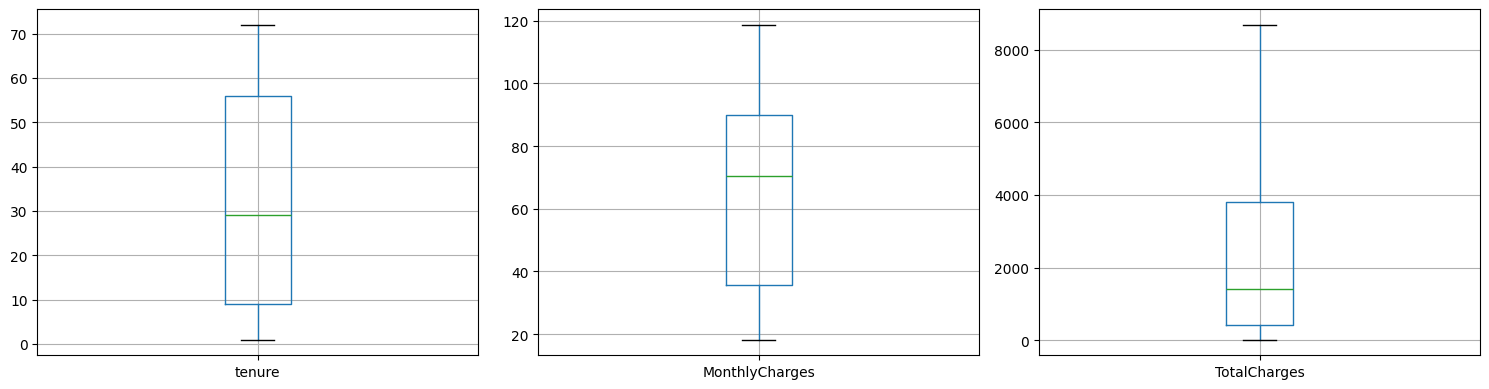

In [17]:
num = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, num):
    df.boxplot(column=c, ax=ax)      # dots beyond the whiskers = potential outliers
plt.tight_layout(); plt.show()

In [18]:
for c in num:
    q1, q3 = df[c].quantile(0.25), df[c].quantile(0.75)
    iqr = q3 - q1
    low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
    n = ((df[c] < low) | (df[c] > high)).sum()
    print(c, '-> outliers:', n)

tenure -> outliers: 0
MonthlyCharges -> outliers: 0
TotalCharges -> outliers: 0


## EDA

In [19]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7010.000000,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388,0.264907
std,0.369180,24.520441,30.064769,2266.820832,0.441315
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.750000,408.312500,0.000000
50%,0.000000,29.000000,70.400000,1403.875000,0.000000
75%,0.000000,56.000000,89.900000,3807.837500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


In [20]:
df.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod
count,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010,7010
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check
freq,3535,3617,4911,6330,3363,3090,3489,3079,3086,3464,2801,2773,3853,4158,2359


Finding dataset is balance or not

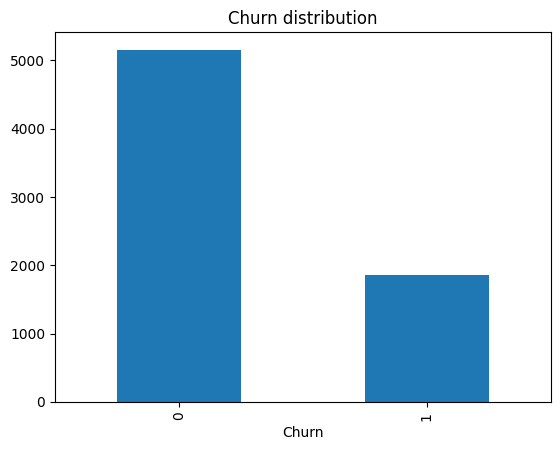

In [21]:
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn distribution'); plt.show()

In [22]:
## The dataset is unbalance

In [23]:
df.groupby('Contract')['Churn'].mean().sort_values(ascending=False)
# People like Month-to-Month Service more. pay by month is more liakable

,Churn
Contract,
Month-to-month,0.426421
One year,0.112772
Two year,0.028487


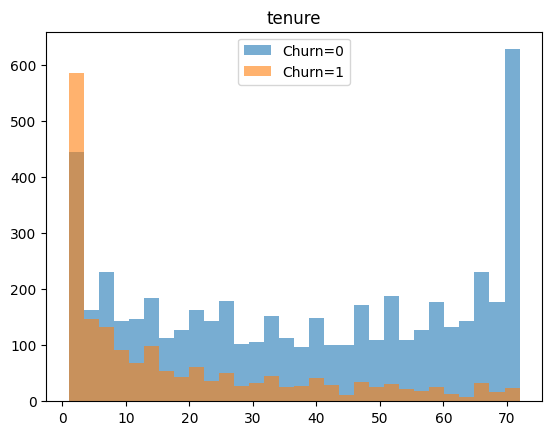

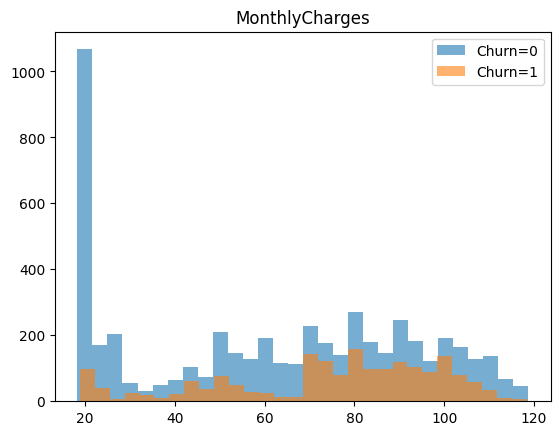

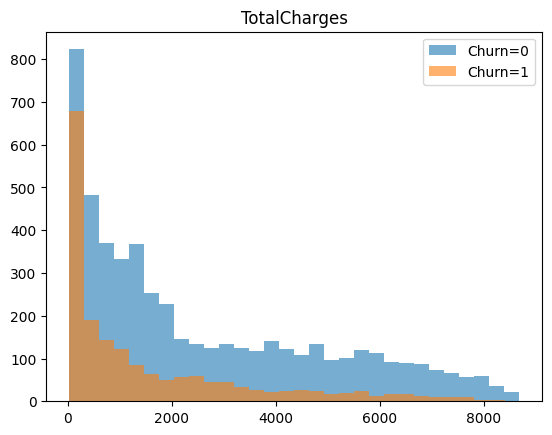

In [24]:
for c in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    for label, sub in df.groupby('Churn'):
        plt.hist(sub[c], bins=30, alpha=0.6, label=f'Churn={label}')
    plt.title(c); plt.legend(); plt.show()

In [25]:
df.groupby('Churn')[['tenure', 'MonthlyCharges', 'TotalCharges']].mean()

,tenure,MonthlyCharges,TotalCharges
Churn,,,
0,37.721133,61.387415,2560.264118
1,18.088853,74.604308,1541.376548


In [26]:
"""
Churners have been around half as long → people leave early
Churners pay ~$13 more/month → high bills push people out
Churners paid less in total → because they left early (less time to accumulate)
"""

'\nChurners have been around half as long → people leave early\nChurners pay ~$13 more/month → high bills push people out\nChurners paid less in total → because they left early (less time to accumulate)\n'

Churn Rate by Categoty

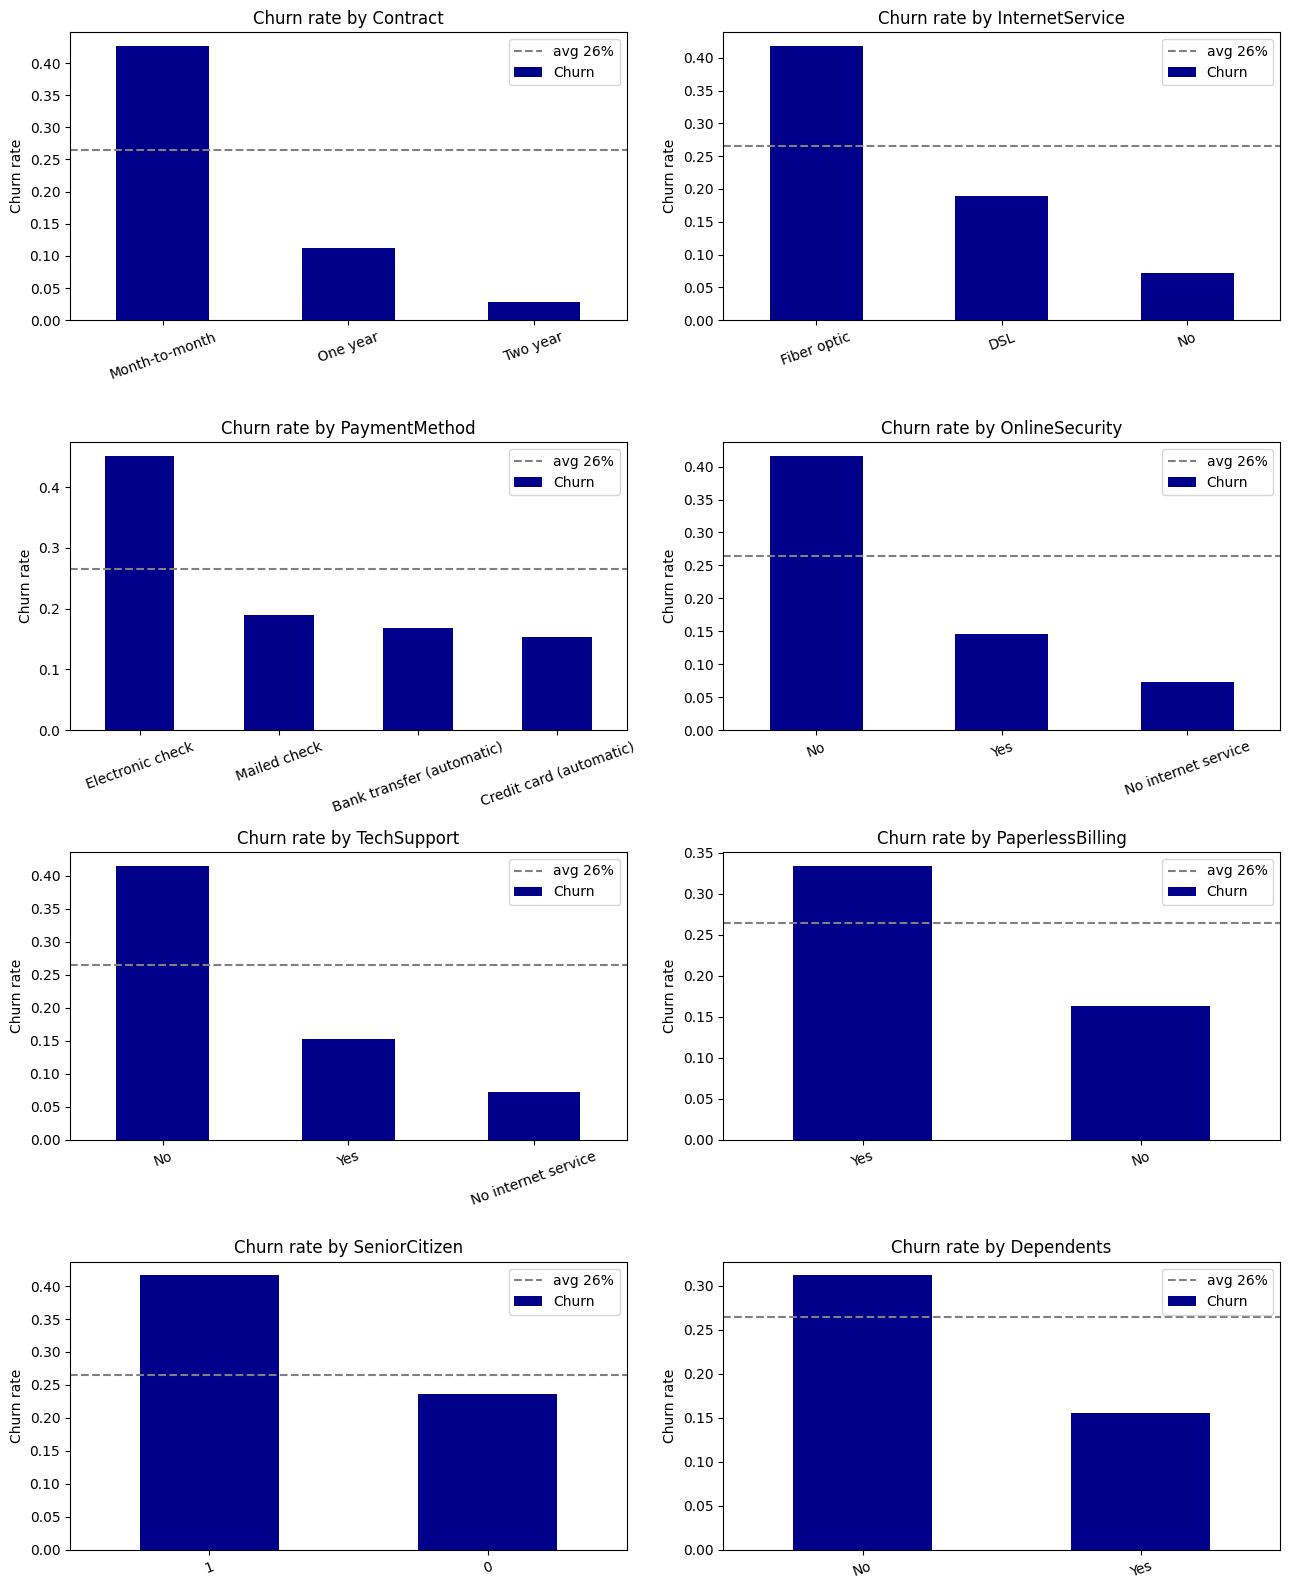

In [27]:
churn_rate = df['Churn'].mean()

cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity',
            'TechSupport', 'PaperlessBilling', 'SeniorCitizen', 'Dependents']

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for ax, col in zip(axes.ravel(), cat_cols):
    rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='darkblue')
    ax.axhline(churn_rate, ls='--', color='gray', label=f'avg {churn_rate:.0%}')
    ax.set_title(f'Churn rate by {col}')
    ax.set_ylabel('Churn rate')
    ax.set_xlabel('')
    ax.legend()
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

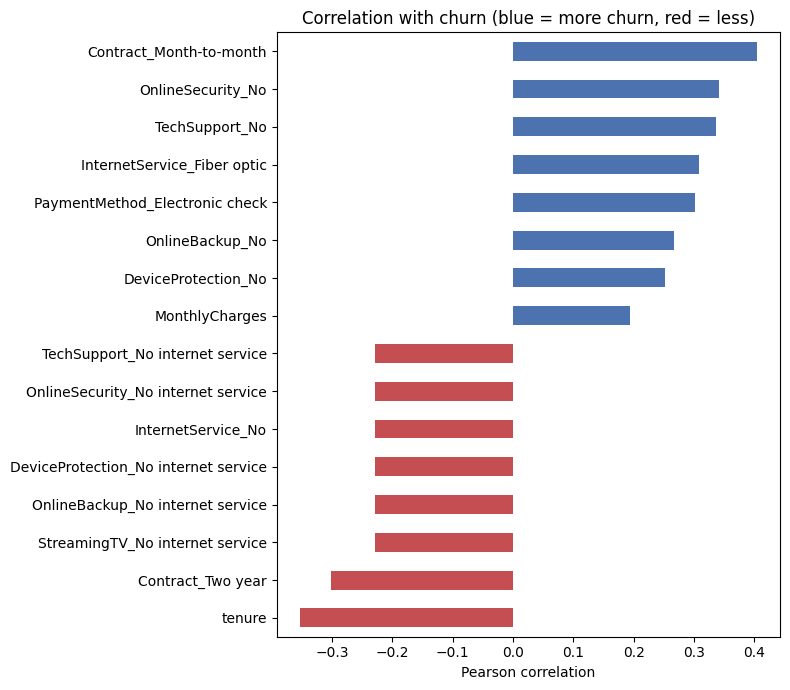

Most correlated with churn:
Contract_Month-to-month           0.404
OnlineSecurity_No                 0.342
TechSupport_No                    0.336
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.301
OnlineBackup_No                   0.267
Name: Churn, dtype: float64


In [28]:
encoded = pd.get_dummies(df, drop_first=False)
corr = encoded.corr()['Churn'].drop('Churn').sort_values()
top = pd.concat([corr.head(8), corr.tail(8)])
ax = top.plot(kind='barh', figsize=(8, 7),
              color=(top > 0).map({True: '#4c72b0', False: '#c44e52'}))
ax.set_title('Correlation with churn (blue = more churn, red = less)')
ax.set_xlabel('Pearson correlation'); plt.tight_layout(); plt.show()
print('Most correlated with churn:'); print(corr.tail(6)[::-1].round(3))

# Training and Evauation

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7010 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7010 non-null   object 
 1   SeniorCitizen     7010 non-null   int64  
 2   Partner           7010 non-null   object 
 3   Dependents        7010 non-null   object 
 4   tenure            7010 non-null   int64  
 5   PhoneService      7010 non-null   object 
 6   MultipleLines     7010 non-null   object 
 7   InternetService   7010 non-null   object 
 8   OnlineSecurity    7010 non-null   object 
 9   OnlineBackup      7010 non-null   object 
 10  DeviceProtection  7010 non-null   object 
 11  TechSupport       7010 non-null   object 
 12  StreamingTV       7010 non-null   object 
 13  StreamingMovies   7010 non-null   object 
 14  Contract          7010 non-null   object 
 15  PaperlessBilling  7010 non-null   object 
 16  PaymentMethod     7010 non-null   object 
 17  

In [30]:
TARGET = 'Churn'
NUMERIC = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
CATEGORICAL = [c for c in df.columns if c not in NUMERIC + [TARGET]]

X = df[NUMERIC + CATEGORICAL]
y = df[TARGET]
print('Features:', X.shape, '| categorical:', len(CATEGORICAL))

Features: (7010, 19) | categorical: 15


Encoding + Scaling

In [31]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), NUMERIC),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CATEGORICAL),
])
# Encoding for these kind of Categorical features should be one hot
# and numerical features will be standardized

Train Test Split

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)

train: (5608, 19) | test: (1402, 19)


Building Pipeline

In [33]:
spw = (y_train == 0).sum() / y_train.sum()

model = Pipeline([
    ('preprocess', preprocessor),
    ('clf', XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                          subsample=0.9, colsample_bytree=0.9,
                          scale_pos_weight=spw,
                          eval_metric='logloss', random_state=42, n_jobs=-1)),
])

Cross Validate

In [34]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(model, X_train, y_train, cv=cv,
                        scoring=['roc_auc', 'f1', 'precision', 'recall'])
for m in ['roc_auc', 'f1', 'precision', 'recall']:
    print(f"CV {m:<10} {scores['test_'+m].mean():.3f}  (+/- {scores['test_'+m].std():.3f})")

CV roc_auc    0.848  (+/- 0.007)
CV f1         0.628  (+/- 0.013)
CV precision  0.525  (+/- 0.016)
CV recall     0.783  (+/- 0.035)


Train and View Pipeline

In [35]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'SeniorCitizen']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'Tech...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=3, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Train Result

In [36]:
proba_train = model.predict_proba(X_train)[:, 1]
pred_train  = (proba_train >= 0.5).astype(int)

print('--- TRAIN scores ---')
print(f'ROC-AUC  : {roc_auc_score(y_train, proba_train):.4f}')
print(f'F1       : {f1_score(y_train, pred_train):.4f}')
print(f'Precision: {precision_score(y_train, pred_train):.4f}')
print(f'Recall   : {recall_score(y_train, pred_train):.4f}')
print('\n', classification_report(y_train, pred_train, target_names=['No churn', 'Churn']))

--- TRAIN scores ---
ROC-AUC  : 0.8855
F1       : 0.6748
Precision: 0.5590
Recall   : 0.8513

               precision    recall  f1-score   support

    No churn       0.93      0.76      0.84      4122
       Churn       0.56      0.85      0.67      1486

    accuracy                           0.78      5608
   macro avg       0.75      0.80      0.76      5608
weighted avg       0.83      0.78      0.79      5608



Test Result

In [37]:
proba_test = model.predict_proba(X_test)[:, 1]
pred_test  = (proba_test >= 0.5).astype(int)

print('--- TEST scores ---')
print(f'ROC-AUC  : {roc_auc_score(y_test, proba_test):.4f}')
print(f'F1       : {f1_score(y_test, pred_test):.4f}')
print(f'Precision: {precision_score(y_test, pred_test):.4f}')
print(f'Recall   : {recall_score(y_test, pred_test):.4f}')
print('\n', classification_report(y_test, pred_test, target_names=['No churn', 'Churn']))

--- TEST scores ---
ROC-AUC  : 0.8431
F1       : 0.6154
Precision: 0.5145
Recall   : 0.7655

               precision    recall  f1-score   support

    No churn       0.90      0.74      0.81      1031
       Churn       0.51      0.77      0.62       371

    accuracy                           0.75      1402
   macro avg       0.71      0.75      0.71      1402
weighted avg       0.80      0.75      0.76      1402



# Saving The Model

In [38]:
joblib.dump(model, 'churn_model.joblib')
print('Saved -> churn_model.joblib')

Saved -> churn_model.joblib
